In [1]:
library(data.table, quietly = TRUE)
library(dplyr, quietly = TRUE)
setwd("/medpop/esp2/mesbah/projects/Meta_GWAS/MetaGWAS_N900k/GWAMA/summary/annovar/")


Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [2]:
list_gwas_sum <- system("ls eaf001/*.csv.gz", intern = TRUE)

head(list_gwas_sum)

[1] "eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasASXL1.AFR.AoU250k_TOPMed72k_MGBB53k.noukbb.csv.gz"  
[2] "eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasASXL1.AFR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.csv.gz"
[3] "eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasASXL1.AMR.AoU250k_TOPMed72k_MGBB53k.noukbb.csv.gz"  
[4] "eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasASXL1.AMR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.csv.gz"
[5] "eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasASXL1.EUR.AoU250k_TOPMed72k_MGBB53k.noukbb.csv.gz"  
[6] "eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasASXL1.EUR.ukbb450k_AoU250k_TOPMed72k_MGBB53k.csv.gz"

In [4]:
system("ls eaf001/*.csv.gz | grep -n 'hasCH.MultiANC' ", intern = TRUE)

[1] "27:eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasCH.MultiANC.AoU250k_TOPMed72k_MGBB53k.noukbb.csv.gz"                   
[2] "28:eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasCH.MultiANC.AoU250k_TOPMed72k_MGBB53k_BioVU54k.noukbb.csv.gz"          
[3] "29:eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasCH.MultiANC.UKBB450k_AoU250k_TOPMed72k_MGBB53k.csv.gz"                 
[4] "30:eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasCH.MultiANC.UKBB450k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.csv.gz"        
[5] "31:eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k.csv.gz"         
[6] "32:eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.csv.gz"
[7] "33:eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasCH.MultiANC.ukbb450k.ukb200k_N193342.ukb250k_N243350.csv.gz"

In [6]:
list_gwas_sum[c(30,32)]

[1] "eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasCH.MultiANC.UKBB450k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.csv.gz"        
[2] "eaf001/eaf001p5e7.annovar.pval_0.0001.GWAMA.chr1_22.hasCH.MultiANC.ukbb200k_ukb250k_AoU250k_TOPMed72k_MGBB53k_BioVU54k.csv.gz"

In [7]:
d1 <- fread(list_gwas_sum[30], header=T)
nrow(d1)
d2 <- fread(list_gwas_sum[32], header=T)
nrow(d2)

dat <- merge(d1, d2, by="SNPID")
nrow(dat)

head(dat)

[1] 3186

[1] 3186

[1] 3186

SNPID,REF.x,ALT.x,AAF.x,BETA.x,SE.x,BETA_95L.x,BETA_95U.x,Z.x,P.x,...,Otherinfo1.y,Otherinfo2.y,Otherinfo3.y,Otherinfo4.y,Otherinfo5.y,Otherinfo7.y,Otherinfo8.y,Otherinfo9.y,Otherinfo10.y,Otherinfo11.y
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
chr10:103896858:G:A,G,A,0.881417,-0.057696,0.011091,-0.079435,-0.035957,-5.201825,2.01e-07,...,.,.,.,chr10,103896858,G,A,.,.,.
chr10:103897558:G:C,G,C,0.882259,-0.057691,0.011081,-0.079408,-0.035973,-5.206451,1.96e-07,...,.,.,.,chr10,103897558,G,C,.,.,.
chr10:103898330:C:T,C,T,0.899300,-0.059852,0.011481,-0.082355,-0.037349,-5.213125,1.90e-07,...,.,.,.,chr10,103898330,C,T,.,.,.
chr10:103900068:T:C,T,C,0.882264,-0.057913,0.011080,-0.079630,-0.036195,-5.226591,1.76e-07,...,.,.,.,chr10,103900068,T,C,.,.,.
chr10:103900944:T:C,T,C,0.881372,-0.058306,0.011087,-0.080037,-0.036575,-5.258761,1.48e-07,...,.,.,.,chr10,103900944,T,C,.,.,.
chr10:103909085:G:A,G,A,0.897132,-0.058479,0.011432,-0.080886,-0.036073,-5.115467,3.19e-07,...,.,.,.,chr10,103909085,G,A,.,.,.


EAF, Pearson's r,  1 


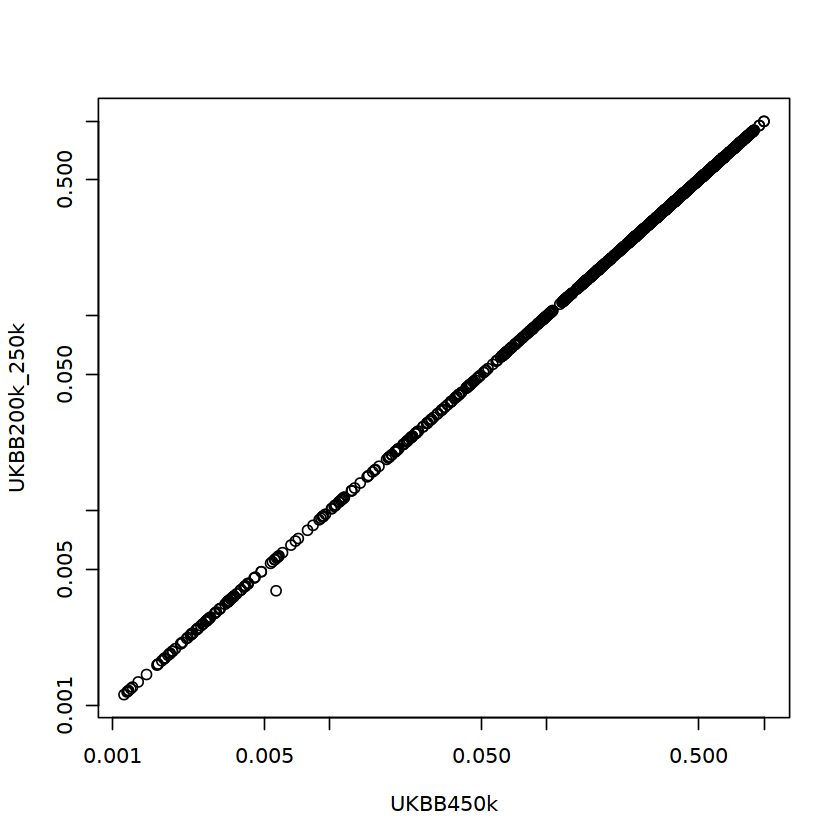

In [9]:
cat("EAF, Pearson's r, ", cor(dat$AAF.x, dat$AAF.y, use="complete"),"\n")
plot(dat$AAF.x, dat$AAF.y, log="xy", xlab = "UKBB450k", ylab = "UKBB200k_250k")

EAF, Pearson's r,  0.9999921 



Call:
lm(formula = dat$BETA.x ~ dat$BETA.y)

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0002503 -0.0000181 -0.0000126  0.0000112  0.0252680 

Coefficients:
             Estimate Std. Error   t value Pr(>|t|)    
(Intercept) 2.045e-06  8.099e-06     0.253    0.801    
dat$BETA.y  1.000e+00  7.026e-05 14237.235   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.0004489 on 3184 degrees of freedom
Multiple R-squared:      1,	Adjusted R-squared:      1 
F-statistic: 2.027e+08 on 1 and 3184 DF,  p-value: < 2.2e-16



Call:
lm(formula = dat$BETA.y ~ dat$BETA.x)

Residuals:
       Min         1Q     Median         3Q        Max 
-0.0252538 -0.0000124  0.0000129  0.0000187  0.0002641 

Coefficients:
              Estimate Std. Error  t value Pr(>|t|)    
(Intercept) -1.703e-06  8.096e-06    -0.21    0.833    
dat$BETA.x   9.997e-01  7.022e-05 14237.24   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.0004488 on 3184 degrees of freedom
Multiple R-squared:      1,	Adjusted R-squared:      1 
F-statistic: 2.027e+08 on 1 and 3184 DF,  p-value: < 2.2e-16


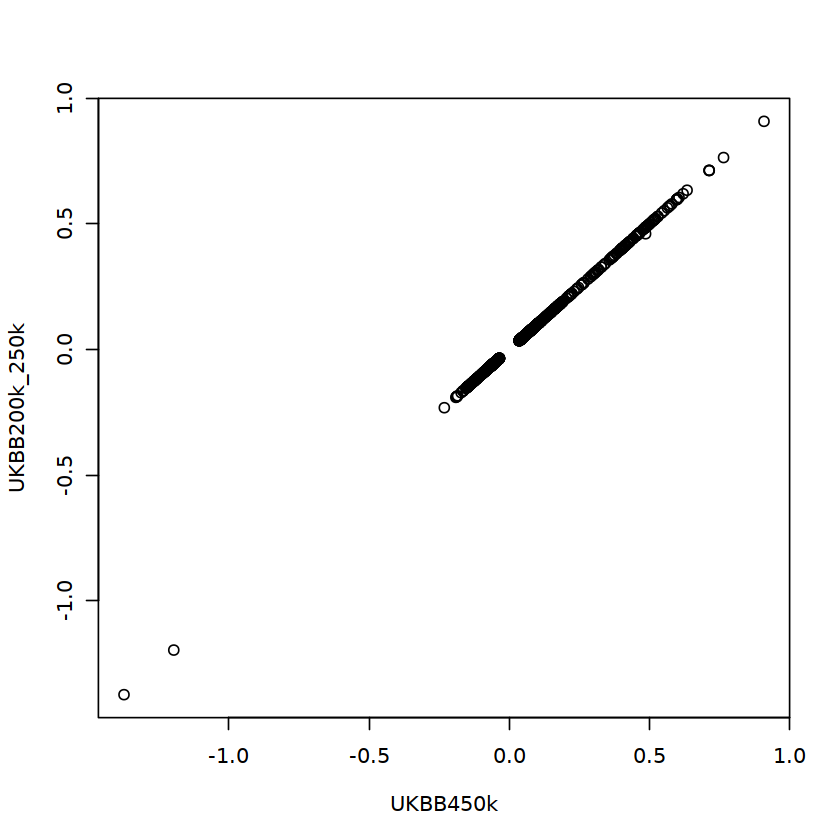

In [12]:
cat("EAF, Pearson's r, ", cor(dat$BETA.x, dat$BETA.y, use="complete"),"\n")
plot(dat$BETA.x, dat$BETA.y, xlab = "UKBB450k", ylab = "UKBB200k_250k")

summary(lm(dat$BETA.x ~ dat$BETA.y))

summary(lm(dat$BETA.y ~ dat$BETA.x))

EAF, Pearson's r,  0.9992942 



Call:
lm(formula = dat$P.x ~ dat$P.y)

Residuals:
       Min         1Q     Median         3Q        Max 
-2.073e-07 -1.300e-11 -1.300e-11  3.300e-11  1.823e-09 

Coefficients:
             Estimate Std. Error  t value Pr(>|t|)    
(Intercept) 1.336e-11  7.139e-11    0.187    0.852    
dat$P.y     9.981e-01  6.650e-04 1501.056   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.681e-09 on 3184 degrees of freedom
Multiple R-squared:  0.9986,	Adjusted R-squared:  0.9986 
F-statistic: 2.253e+06 on 1 and 3184 DF,  p-value: < 2.2e-16



Call:
lm(formula = dat$P.y ~ dat$P.x)

Residuals:
       Min         1Q     Median         3Q        Max 
-1.248e-09 -6.000e-11 -4.800e-11 -4.800e-11  2.078e-07 

Coefficients:
             Estimate Std. Error  t value Pr(>|t|)    
(Intercept) 4.827e-11  7.147e-11    0.675    0.499    
dat$P.x     1.000e+00  6.665e-04 1501.056   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 3.685e-09 on 3184 degrees of freedom
Multiple R-squared:  0.9986,	Adjusted R-squared:  0.9986 
F-statistic: 2.253e+06 on 1 and 3184 DF,  p-value: < 2.2e-16


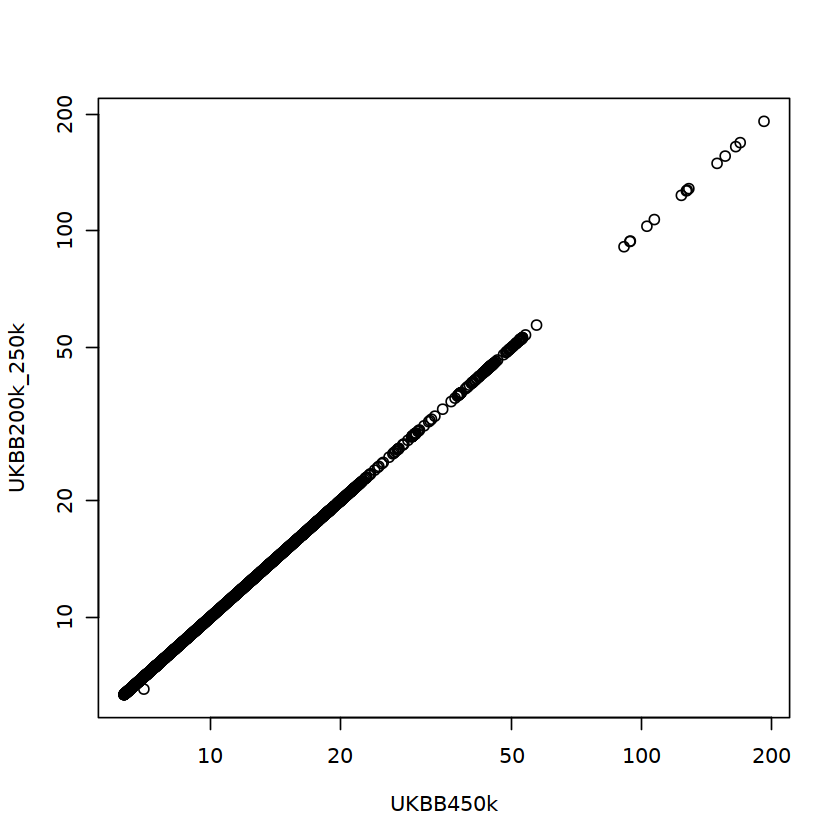

In [13]:
cat("EAF, Pearson's r, ", cor(dat$P.x, dat$P.y, use="complete"),"\n")
plot(-log10(dat$P.x), -log10(dat$P.y), log="xy", xlab = "UKBB450k", ylab = "UKBB200k_250k")

summary(lm(dat$P.x ~ dat$P.y))

summary(lm(dat$P.y ~ dat$P.x))

In [14]:
cat("P<=5e-8 \n")
table(dat$P.x<=5e-8, exclude=NULL)

table(dat$P.y<=5e-8, exclude=NULL)

cat("P<5e-8 \n")

table(dat$P.x<5e-8, exclude=NULL)

table(dat$P.y<5e-8, exclude=NULL)

cat("P<5e-15 \n")

table(dat$P.x<5e-15, exclude=NULL)

table(dat$P.y<5e-15, exclude=NULL)

cat("P<5e-20 \n")

table(dat$P.x<5e-20, exclude=NULL)

table(dat$P.y<5e-20, exclude=NULL)

cat("P<5e-50 \n")

table(dat$P.x<5e-50, exclude=NULL)

table(dat$P.y<5e-50, exclude=NULL)

P<=5e-8 



FALSE  TRUE 
  603  2583 


FALSE  TRUE 
  604  2582 

P<5e-8 



FALSE  TRUE 
  605  2581 

...


FALSE  TRUE 
 2733   453 


FALSE  TRUE 
 2733   453 

P<5e-50 



FALSE  TRUE 
 3123    63 


FALSE  TRUE 
 3123    63 

In [16]:
dat[which.min(dat$P.x),]
dat[which.min(dat$P.y),]

SNPID,REF.x,ALT.x,AAF.x,BETA.x,SE.x,BETA_95L.x,BETA_95U.x,Z.x,P.x,...,Otherinfo1.y,Otherinfo2.y,Otherinfo3.y,Otherinfo4.y,Otherinfo5.y,Otherinfo7.y,Otherinfo8.y,Otherinfo9.y,Otherinfo10.y,Otherinfo11.y
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
chr5:1285859:C:A,C,A,0.314045,0.211441,0.007138,0.197451,0.22543,29.62344,8.82e-193,...,.,.,.,chr5,1285859,C,A,.,.,.


SNPID,REF.x,ALT.x,AAF.x,BETA.x,SE.x,BETA_95L.x,BETA_95U.x,Z.x,P.x,...,Otherinfo1.y,Otherinfo2.y,Otherinfo3.y,Otherinfo4.y,Otherinfo5.y,Otherinfo7.y,Otherinfo8.y,Otherinfo9.y,Otherinfo10.y,Otherinfo11.y
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
chr5:1285859:C:A,C,A,0.314045,0.211441,0.007138,0.197451,0.22543,29.62344,8.82e-193,...,.,.,.,chr5,1285859,C,A,.,.,.


In [17]:
d3 <- fread(list_gwas_sum[29], header=T)
nrow(d3)
d4 <- fread(list_gwas_sum[31], header=T)
nrow(d4)

dat2 <- merge(d3, d4, by="SNPID")
nrow(dat2)

[1] 3184

[1] 3184

[1] 3184

In [18]:
dat2[which.min(dat2$P.x),]
dat2[which.min(dat2$P.y),]

SNPID,REF.x,ALT.x,AAF.x,BETA.x,SE.x,BETA_95L.x,BETA_95U.x,Z.x,P.x,...,Otherinfo1.y,Otherinfo2.y,Otherinfo3.y,Otherinfo4.y,Otherinfo5.y,Otherinfo7.y,Otherinfo8.y,Otherinfo9.y,Otherinfo10.y,Otherinfo11.y
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
chr5:1285859:C:A,C,A,0.312838,0.212277,0.007254,0.19806,0.226494,29.26481,3.44e-188,...,.,.,.,chr5,1285859,C,A,.,.,.


SNPID,REF.x,ALT.x,AAF.x,BETA.x,SE.x,BETA_95L.x,BETA_95U.x,Z.x,P.x,...,Otherinfo1.y,Otherinfo2.y,Otherinfo3.y,Otherinfo4.y,Otherinfo5.y,Otherinfo7.y,Otherinfo8.y,Otherinfo9.y,Otherinfo10.y,Otherinfo11.y
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
chr5:1285859:C:A,C,A,0.312838,0.212277,0.007254,0.19806,0.226494,29.26481,3.44e-188,...,.,.,.,chr5,1285859,C,A,.,.,.


In [20]:
table(dat$SNPID %in% dat2$SNPID)
table(dat2$SNPID %in% dat$SNPID)


FALSE  TRUE 
   92  3094 


FALSE  TRUE 
   90  3094 

In [21]:
cat("P<=5e-8 \n")
table(dat2$P.x<=5e-8, exclude=NULL)

table(dat2$P.y<=5e-8, exclude=NULL)

cat("P<5e-8 \n")

table(dat2$P.x<5e-8, exclude=NULL)

table(dat2$P.y<5e-8, exclude=NULL)

cat("P<5e-15 \n")

table(dat2$P.x<5e-15, exclude=NULL)

table(dat2$P.y<5e-15, exclude=NULL)

cat("P<5e-20 \n")

table(dat2$P.x<5e-20, exclude=NULL)

table(dat2$P.y<5e-20, exclude=NULL)

cat("P<5e-50 \n")

table(dat2$P.x<5e-50, exclude=NULL)

table(dat2$P.y<5e-50, exclude=NULL)

P<=5e-8 



FALSE  TRUE 
  642  2542 


FALSE  TRUE 
  643  2541 

P<5e-8 



FALSE  TRUE 
  643  2541 

...


FALSE  TRUE 
 2677   507 


FALSE  TRUE 
 2677   507 

P<5e-50 



FALSE  TRUE 
 3120    64 


FALSE  TRUE 
 3120    64 